# Equity curve — Donchian breakout on ALGO

Runs the strategy in `donchian.py` (long when price breaks above the past `LOOKBACK`-day high, short when it breaks below the past `LOOKBACK`-day low, exit when price crosses the middle band) through the same PnL loop as `eval.py` — identical commissions, position clipping, and scoring.

Backtests the **first 250 days** of `prices.txt`. ALGO is instrument 0, the SPECIAL instrument: 0.2bp commission and a $100k position limit.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# works whether the notebook runs with cwd = repo root or this folder
ROOT = Path.cwd() if (Path.cwd() / "prices.txt").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "algo_donchian"))
from donchian import DonchianStrategy, INST

prcAll = pd.read_csv(ROOT / "prices.txt", sep=r"\s+", header=0, index_col=None).values.T
nInst, nt = prcAll.shape

N_DAYS = 250
prcHist = prcAll[:, :N_DAYS]
print(f"{nInst} instruments; backtesting first {N_DAYS} of {nt} days")

51 instruments; backtesting first 250 of 500 days


In [2]:
def run_equity(strategy, prcHist):
    """eval.py's PnL loop, recording portfolio value, trade state, and bands."""
    nInst, nt = prcHist.shape
    commRate = np.full(nInst, 0.0001)
    commRate[0] = 0.00002
    dlrPosLimit = np.full(nInst, 10_000.0)
    dlrPosLimit[0] = 100_000.0

    startDay = strategy.lookback + 1
    cash, value, comm = 0.0, 0.0, 0.0
    curPos = np.zeros(nInst)
    tradeDir = 0
    bands = (np.nan, np.nan, np.nan)
    rows = []

    for t in range(startDay, nt + 1):
        prcSoFar = prcHist[:, :t]
        curPrices = prcSoFar[:, -1]
        if t < nt:
            newPos = strategy.step(prcSoFar)
            tradeDir = strategy.tradeDir
            bands = strategy.lastBands
            posLimits = (dlrPosLimit / curPrices).astype(int)
            newPos = np.clip(newPos, -posLimits, posLimits).astype(int)
        else:
            newPos = np.array(curPos)

        deltaPos = newPos - curPos
        cash -= curPrices.dot(deltaPos) + comm
        dvolumes = curPrices * np.abs(deltaPos)
        comm = np.sum(dvolumes * commRate)
        curPos = np.array(newPos)
        newValue = cash + curPos.dot(curPrices)
        rows.append({
            "day": t,
            "value": newValue,
            "todayPL": newValue - value,
            "tradeDir": tradeDir,
            "price": curPrices[INST],
            "upper": bands[0],
            "middle": bands[1],
            "lower": bands[2],
            "scored": t > startDay,
        })
        value = newValue

    return pd.DataFrame(rows)

In [3]:
strategy = DonchianStrategy()  # picks up the defaults in donchian.py
hist = run_equity(strategy, prcHist)

pll = hist.loc[hist["scored"], "todayPL"].values
mu, sd = pll.mean(), pll.std()
sharpe = np.sqrt(250) * mu / sd if sd > 0 else 0.0
scoreVal = mu * sharpe**2 / (sharpe**2 + 1.0) if mu > 0 and sd > 1e-10 else mu
d = hist["tradeDir"].values
entries = int(np.sum((d[1:] != 0) & (d[:-1] == 0)) + (d[0] != 0))

print(f"LOOKBACK={strategy.lookback}")
print(f"scored days:   {len(pll)}")
print(f"mean(PL):      {mu:.2f}")
print(f"StdDev(PL):    {sd:.2f}")
print(f"annSharpe:     {sharpe:.2f}")
print(f"Score:         {scoreVal:.2f}")
print(f"entries:       {entries}")
print(f"final value:   {hist['value'].iloc[-1]:.2f}")

LOOKBACK=20
scored days:   229
mean(PL):      -47.43
StdDev(PL):    777.60
annSharpe:     -0.96
Score:         -47.43
entries:       13
final value:   -10860.62


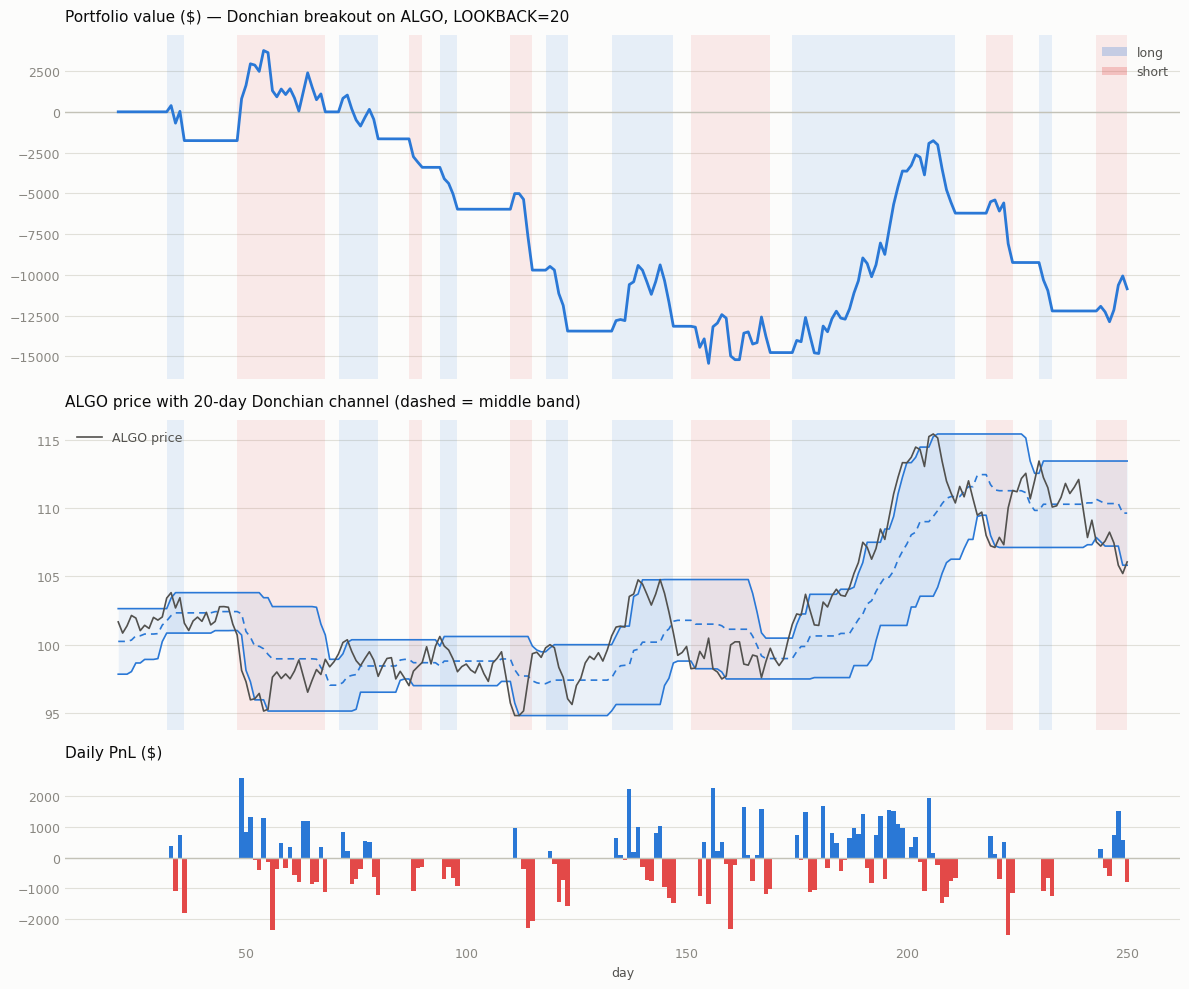

In [4]:
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE, RED = "#2a78d6", "#e34948"


def _spans(mask, days):
    """Contiguous (start, end) day spans where mask is True."""
    out, start = [], None
    for i, m in enumerate(mask):
        if m and start is None:
            start = days[i]
        elif not m and start is not None:
            out.append((start, days[i]))
            start = None
    if start is not None:
        out.append((start, days[-1]))
    return out


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
    for s in ax.spines.values():
        s.set_visible(False)


def _shadeTrades(ax):
    for a, b in _spans(dirs == 1, days):
        ax.axvspan(a, b, color=BLUE, alpha=0.10, linewidth=0)
    for a, b in _spans(dirs == -1, days):
        ax.axvspan(a, b, color=RED, alpha=0.10, linewidth=0)


days = hist["day"].values
dirs = hist["tradeDir"].values

fig, (ax1, axc, ax2) = plt.subplots(
    3, 1, figsize=(12, 10), sharex=True,
    gridspec_kw={"height_ratios": [2, 1.8, 1]},
)
fig.patch.set_facecolor(SURFACE)

_shadeTrades(ax1)
ax1.axhline(0, color=BASELINE, linewidth=1)
ax1.plot(days, hist["value"], color=BLUE, linewidth=2)
_style(ax1)
ax1.set_title(
    f"Portfolio value ($) — Donchian breakout on ALGO, LOOKBACK={strategy.lookback}",
    color=INK, fontsize=11, loc="left", pad=10,
)
ax1.legend(
    handles=[
        Patch(facecolor=BLUE, alpha=0.25, label="long"),
        Patch(facecolor=RED, alpha=0.25, label="short"),
    ],
    frameon=False, loc="upper right", fontsize=9, labelcolor=INK2,
)

_shadeTrades(axc)
axc.fill_between(days, hist["lower"], hist["upper"], color=BLUE, alpha=0.08, linewidth=0)
axc.plot(days, hist["upper"], color=BLUE, linewidth=1.2)
axc.plot(days, hist["lower"], color=BLUE, linewidth=1.2)
axc.plot(days, hist["middle"], color=BLUE, linewidth=1.2, linestyle=(0, (4, 3)))
axc.plot(days, hist["price"], color=INK2, linewidth=1.2, label="ALGO price")
_style(axc)
axc.set_title(
    f"ALGO price with {strategy.lookback}-day Donchian channel (dashed = middle band)",
    color=INK, fontsize=11, loc="left", pad=10,
)
axc.legend(frameon=False, loc="upper left", fontsize=9, labelcolor=INK2)

plCol = np.where(hist["todayPL"] >= 0, BLUE, RED)
ax2.axhline(0, color=BASELINE, linewidth=1)
ax2.bar(days, hist["todayPL"], width=1.0, color=plCol, linewidth=0)
_style(ax2)
ax2.set_title("Daily PnL ($)", color=INK, fontsize=11, loc="left", pad=10)
ax2.set_xlabel("day", color=INK2, fontsize=9)

fig.tight_layout()
plt.show()